# Real Data Analysis

*Date: 1 July, 2026 - BY: Tomás Silva*

* Data Sample: *753829*
* Type: *unwounded*
* Subtype: *Wound*
* X-number: *52*
* Y-number: *145*
* Nº points: *7468*


### 0. Imports and Configurations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context('notebook')
sns.set_style('white')
my_cmap = sns.color_palette("viridis", as_cmap=True)
from scipy.ndimage import label, binary_fill_holes, binary_opening
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
import hdbscan

# Sample 1

### 1. Import Data

In [2]:
file_path = 'Data/753829 IQ_fitting.csv'
df_import  = pd.read_csv(file_path)

z_parameters = ['total SAXS intensity', 'area under third order curve', 'D_period']
df = df_import.dropna(subset=z_parameters).copy()

df.head()

,x,y,total SAXS intensity,total_SAXS_norm_0_1,area under third order curve,collagen_third_norm_0_1,percentage_above_baseline,max_recorded_intensity,firstmoment,secondmoment,...,wMu,firstmoment_lu,secondmoment_lu,thirdmoment_lu,skewness_lu,D_period,peak_width,wp,peak_amplitude,fibril_radius
0,0,0,0.761302,0.256197,0.000000,1.000000e-09,35.318771,0.015390,0.291159,0.0849,...,0.015918,0.299098,0.0895,0.026758,-0.633265,63.041993,0.001,0.004760,1,560.272132
1,1,0,0.767918,0.258971,0.000000,1.000000e-09,14.286950,0.040639,0.274783,0.0755,...,0.187551,0.306105,0.0938,0.028730,2.599635,62.623109,0.001,0.056453,1,47.237054
2,2,0,0.753616,0.252974,0.000379,7.088826e-02,88.423642,0.033713,0.286602,0.0822,...,0.027755,0.295121,0.0871,0.025705,-0.084105,63.896800,0.001,0.008188,1,325.689598
3,3,0,0.757034,0.254407,0.000000,1.000000e-09,47.013759,0.027789,0.285605,0.0816,...,0.039592,0.290273,0.0843,0.024459,-0.324420,64.998469,0.001,0.011482,1,232.255007
4,4,0,0.757243,0.254495,0.000000,1.000000e-09,24.287431,0.018811,0.287495,0.0828,...,0.039592,0.288280,0.0831,0.023959,-0.404771,65.449847,0.001,0.011402,1,233.867889


### 2. Plots

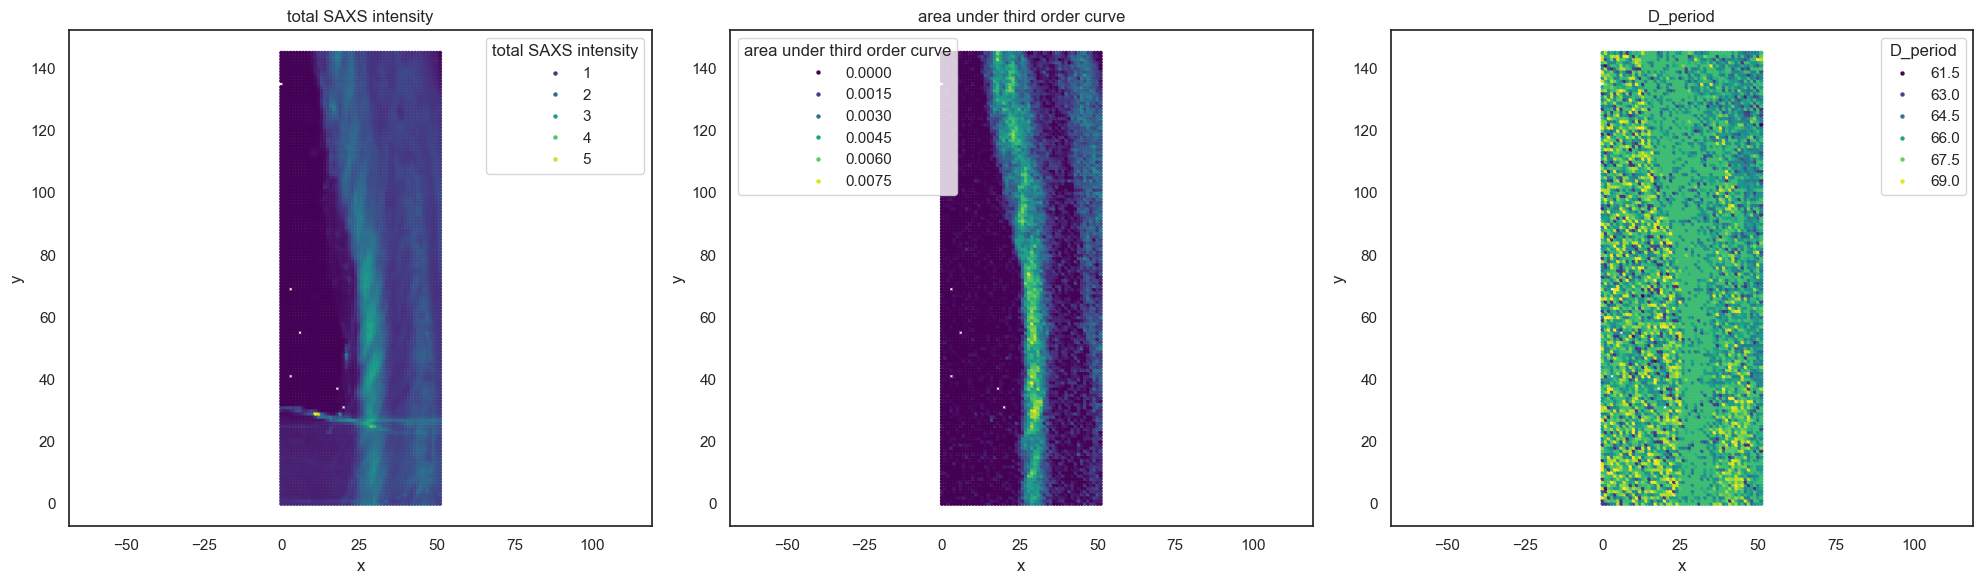

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, param in enumerate(z_parameters):
    sns.scatterplot(
        data=df,
        x='x',
        y='y',
        hue=param,
        palette=my_cmap,
        edgecolor='none',
        s=10,
        ax=axes[i]
    )

    axes[i].set_title(param)
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

#### 2.1. Individual plots

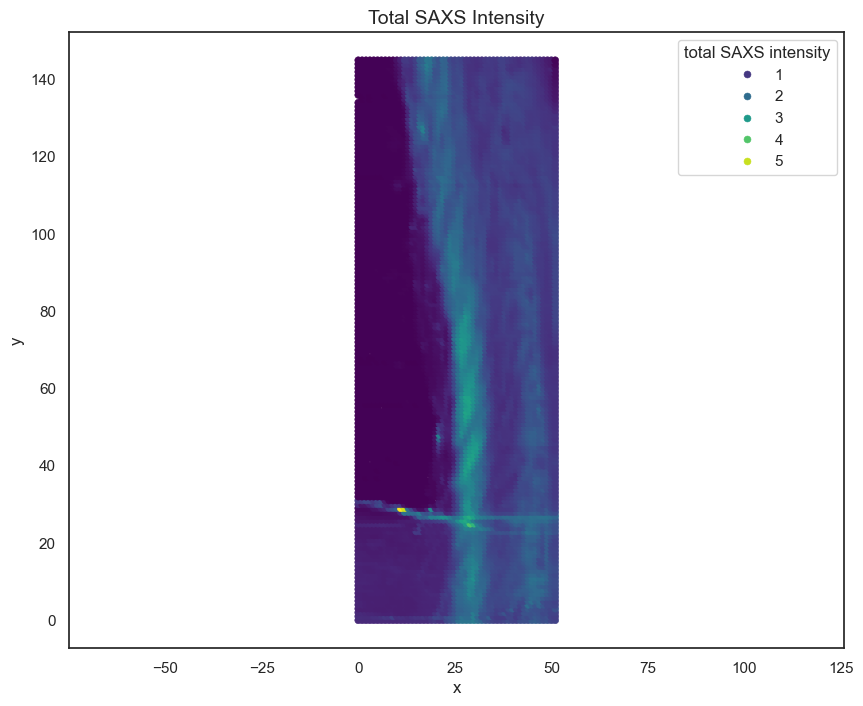

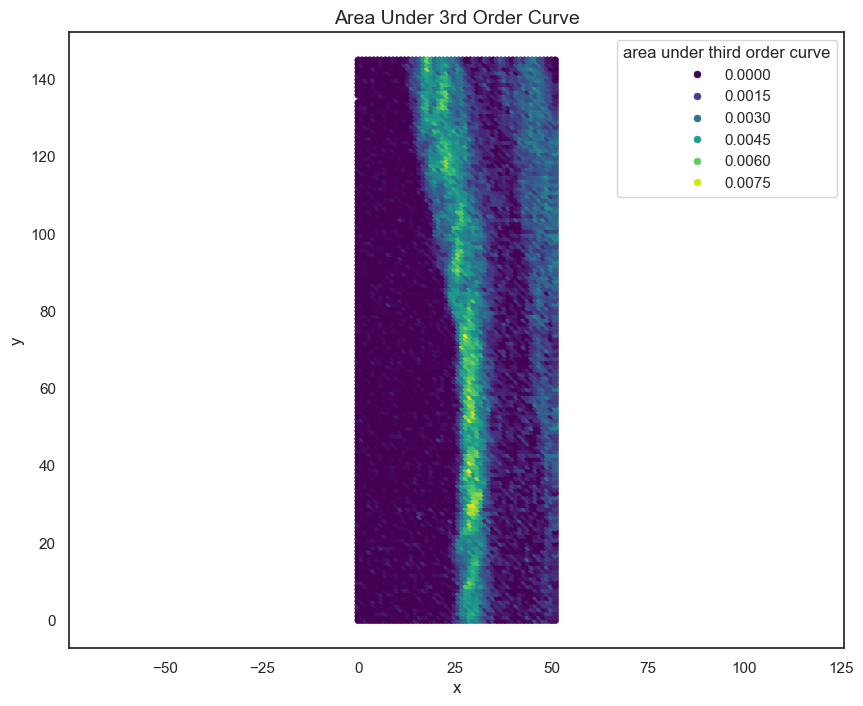

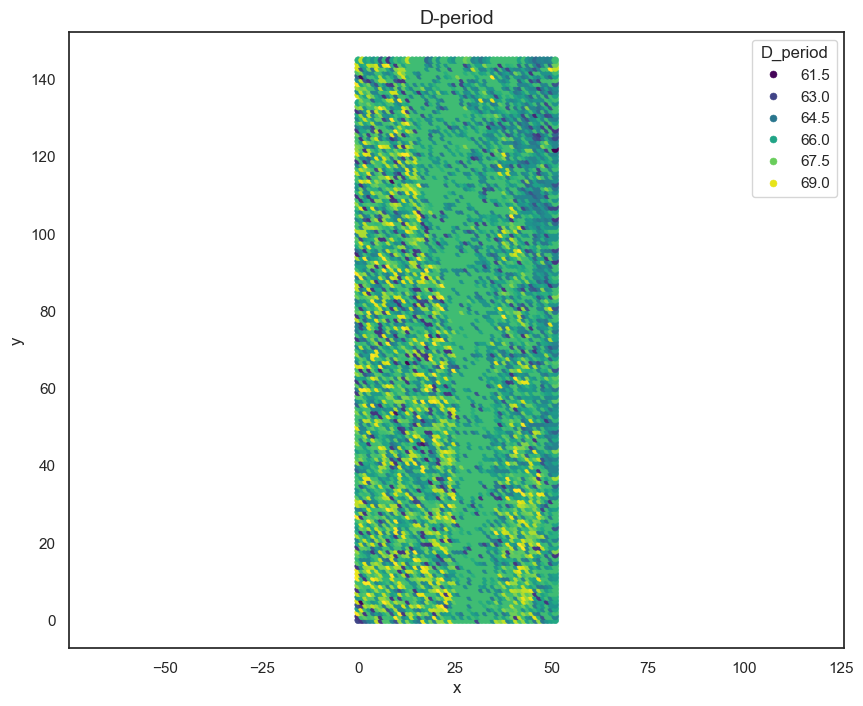

In [4]:
# Total SAXS Intensity
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='x', 
    y='y', 
    hue='total SAXS intensity', 
    palette=my_cmap,   
    edgecolor=None, 
    s=25
)
plt.title('Total SAXS Intensity', fontsize=14)
plt.axis('equal')
plt.show()

# Area Under 3rd Order Curve
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='x', 
    y='y', 
    hue='area under third order curve', 
    palette=my_cmap,   
    edgecolor=None, 
    s=25
)
plt.title('Area Under 3rd Order Curve', fontsize=14)
plt.axis('equal')
plt.show()

# D Period
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='x', 
    y='y', 
    hue='D_period', 
    palette=my_cmap,   
    edgecolor=None, 
    s=25
)
plt.title('D-period', fontsize=14)
plt.axis('equal')
plt.show()

### 3. Segmentation

#### 3.1 Data Processing and Masking

This step isolates the actual tissue sample from the background air and mounting artifacts (like tape/wax). Because the artifacts share the same bright X-ray intensity as the real tissue, a simple color cutoff won't work—it would keep the tape or accidentally delete real skin.

To fix this, we use a 4-step pipeline that looks at both intensity (color) and topology (shape/connections):

 - **Step 1**: `K-Means Clustering` (The Color Split): We group all pixels into two buckets: "Dark" (empty air) and "Bright" (tissue + artifacts). We use K-Means instead of guessing a manual threshold number because K-Means automatically finds the perfect mathematical dividing line for the specific lighting of this exact file.

 - **Step 2**: `Morphological Opening` (The Scalpel): K-Means kept the artifact because it's bright, and it’s physically touching our tissue via a thin thread of pixels. "Opening" digitally shrinks the outer borders of everything by 1 pixel. Because the connecting thread is very thin, this shrinkage completely snaps it. The code then immediately dilates (grows) the shapes back to their normal size, but that snapped thread stays broken.

 - **Step 3**: `Connected Components` (Island Finding): Now we treat the grid like a map. The code finds every isolated cluster of touching pixels (islands) and measures their area. Since the real tissue is the largest solid object, we tell the computer to keep the biggest "island" and instantly delete all the smaller, disconnected chunks (like the freshly detached tape and edge noise).

 - **Step 4**: `Hole Filling` (The Patch): Sometimes K-Means accidentally flags slightly darker pixels deep inside the tissue as "air". This final step scans the interior of our isolated tissue mask and fills in any trapped empty holes, leaving a perfectly solid, continuous dataset ready for analysis.

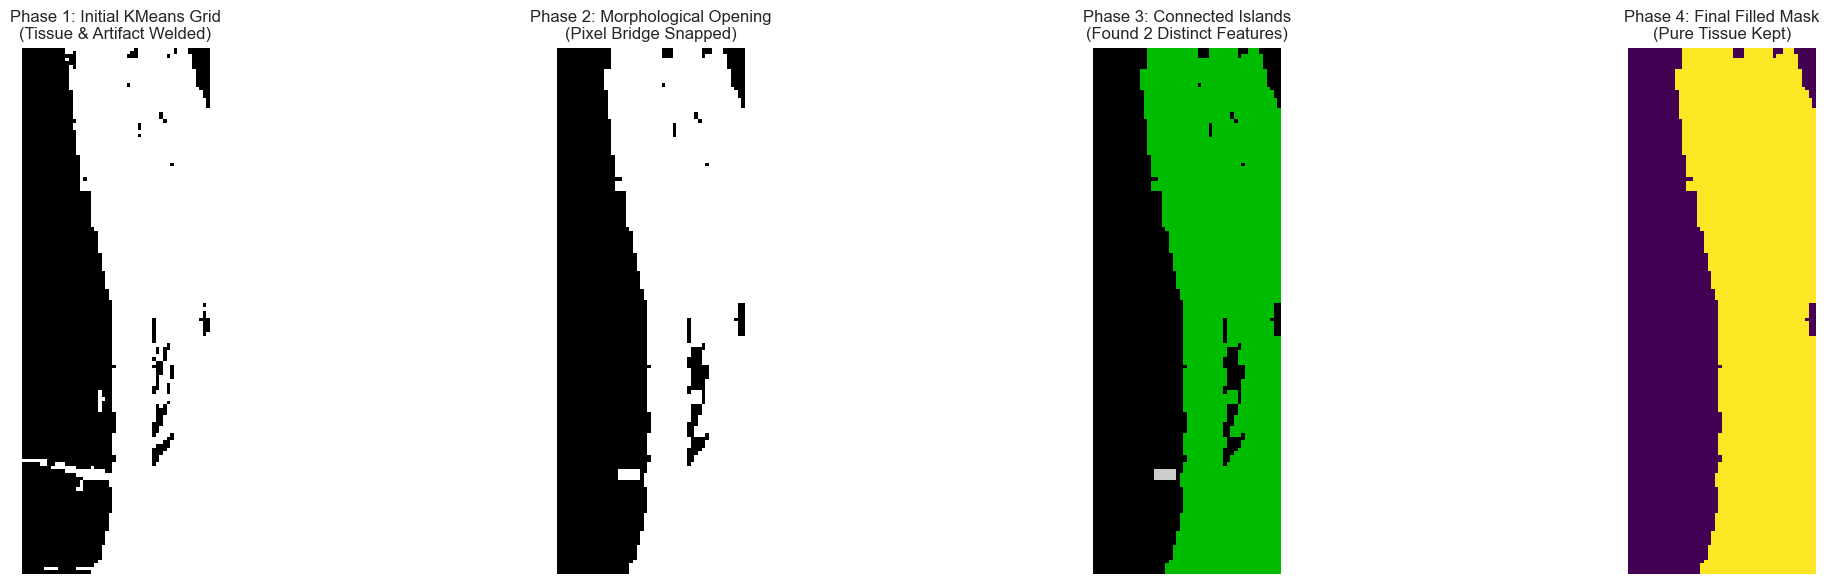

In [5]:
# Map the raw spatial coordinates to a zero-indexed integer pixel grid
x_grid = (df['x'] - df['x'].min()).astype(int)
y_grid = (df['y'] - df['y'].min()).astype(int)

grid_width = x_grid.max() + 1
grid_height = y_grid.max() + 1
grid = np.zeros((grid_height, grid_width))

# Use 2-cluster KMeans to segment the background air from foreground objects based on intensity
intensities = df['total SAXS intensity'].values.reshape(-1, 1)
kmeans_seg = KMeans(n_clusters=2, random_state=42, n_init=10).fit(intensities)

# Identify the cluster ID representing the brighter foreground tissue
bright_cluster = np.argmax(kmeans_seg.cluster_centers_)
foreground_mask = (kmeans_seg.labels_ == bright_cluster).astype(int)
grid[y_grid, x_grid] = foreground_mask

# Apply morphological opening to sever thin pixel bridges connecting artifacts to the tissue
grid_disconnected = binary_opening(grid, structure=np.ones((3, 3)))

# Group physically touching pixels into isolated components (islands)
labeled_grid, num_features = label(grid_disconnected)
sizes = np.bincount(labeled_grid.ravel())
sizes[0] = 0  # Exclude the background air count

# Isolate the single largest continuous mass, which represents the true tissue sample
largest_island_id = sizes.argmax()
clean_mask = (labeled_grid == largest_island_id)

# Fill any small internal structural voids within the extracted tissue mask
clean_mask = binary_fill_holes(clean_mask)

# Map the grid mask back onto the dataframe and filter rows
df['is_real_tissue'] = clean_mask[y_grid, x_grid]
df_clean = df[df['is_real_tissue'] == 1].copy()

print(f"Original points: {len(df)}")
print(f"Cleaned tissue points: {len(df_clean)}")

Original points: 7586
Cleaned tissue points: 4409


#### 3.2. Visualisation

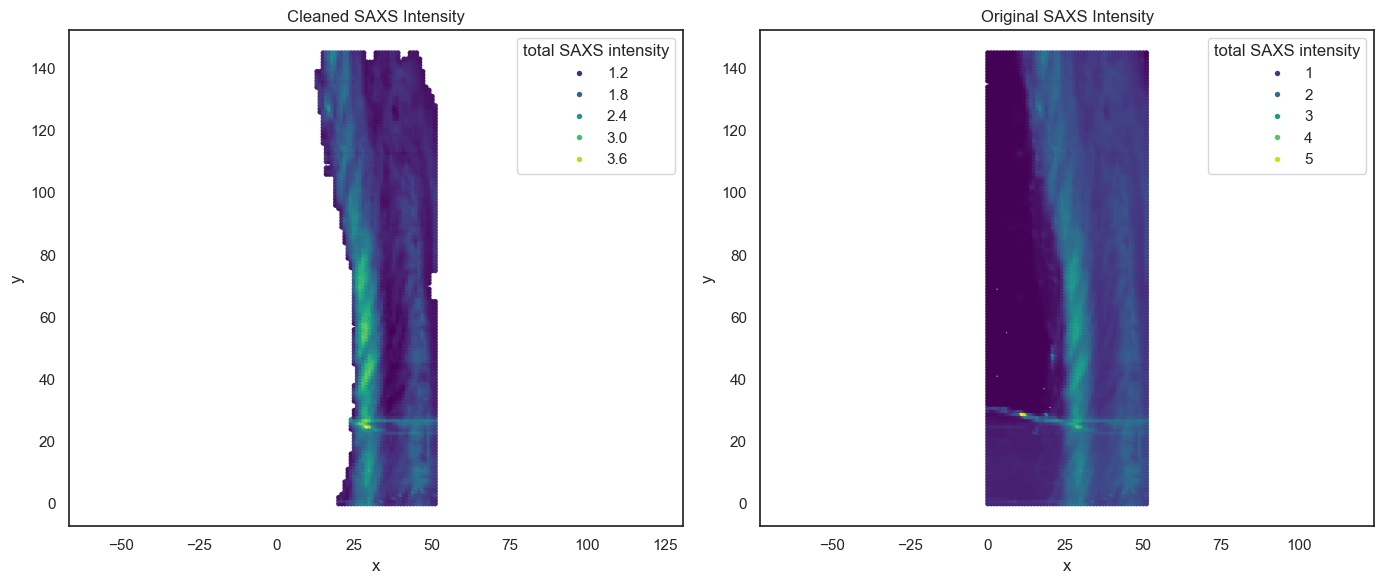

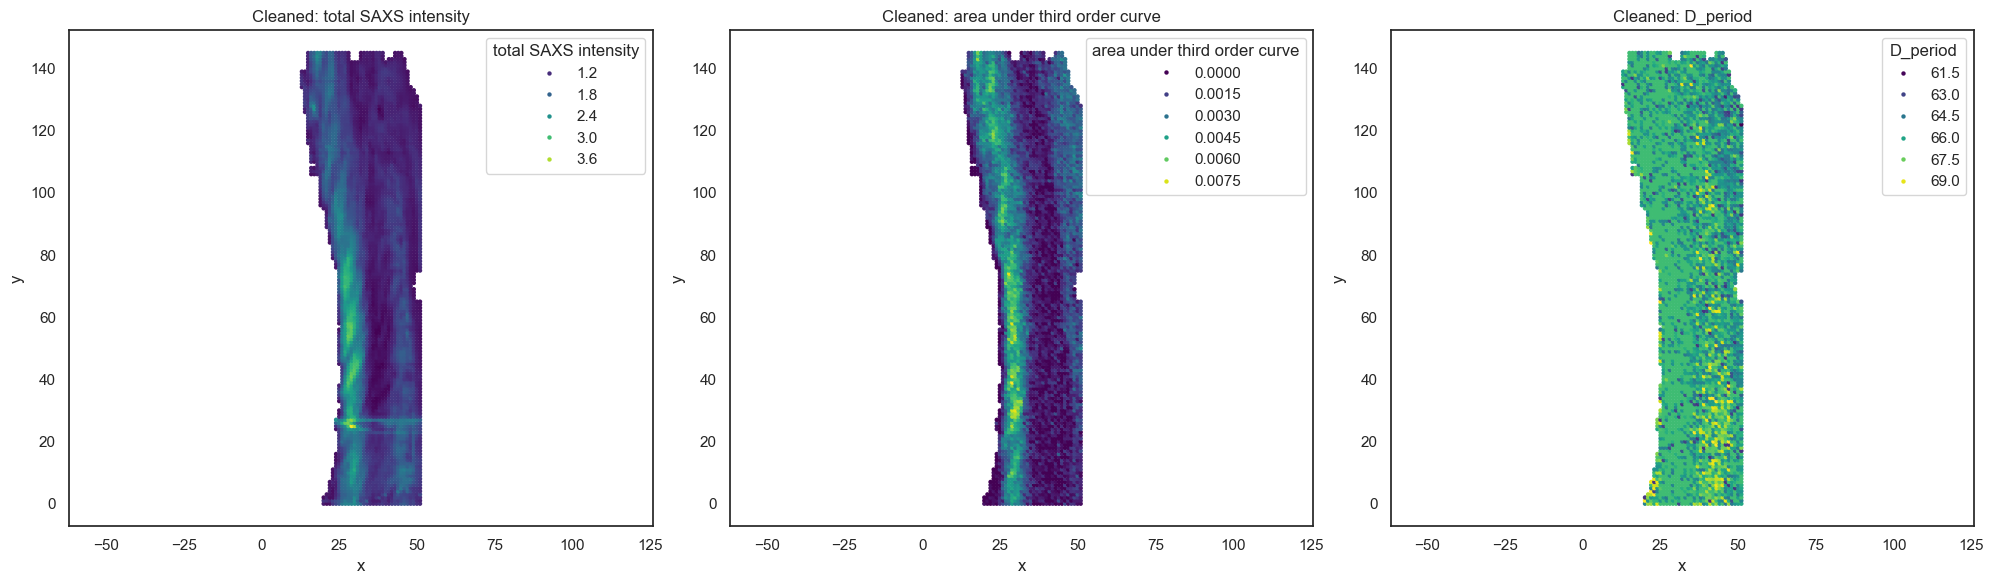

In [6]:
# 4. Plot the cleaned SAXS Intensity and the original SAXS Intensity side-by-side for comparison
fig, axes = plt.subplots(1,2, figsize=(14, 6))

# Cleaned SAXS Intensity
sns.scatterplot(
    data=df_clean, x='x', y='y', hue='total SAXS intensity',
    palette=my_cmap, edgecolor='none', s=15, ax=axes[0]
)
axes[0].set_title("Cleaned SAXS Intensity")
axes[0].axis('equal')

# Original SAXS Intensity
sns.scatterplot(
    data=df, x='x', y='y', hue='total SAXS intensity',
    palette=my_cmap, edgecolor='none', s=15, ax=axes[1]
)
axes[1].set_title("Original SAXS Intensity")
axes[1].axis('equal')

plt.tight_layout()
plt.show()


# 4. Plot all 3 parameters side-by-side to verify
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, param in enumerate(z_parameters):
    sns.scatterplot(
        data=df_clean,
        x='x',
        y='y',
        hue=param,
        palette=my_cmap if param != 'D_period' else 'viridis',
        edgecolor='none',
        s=10,
        ax=axes[i]
    )
    axes[i].set_title(f"Cleaned: {param}")
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

#### 3.3 Explanation

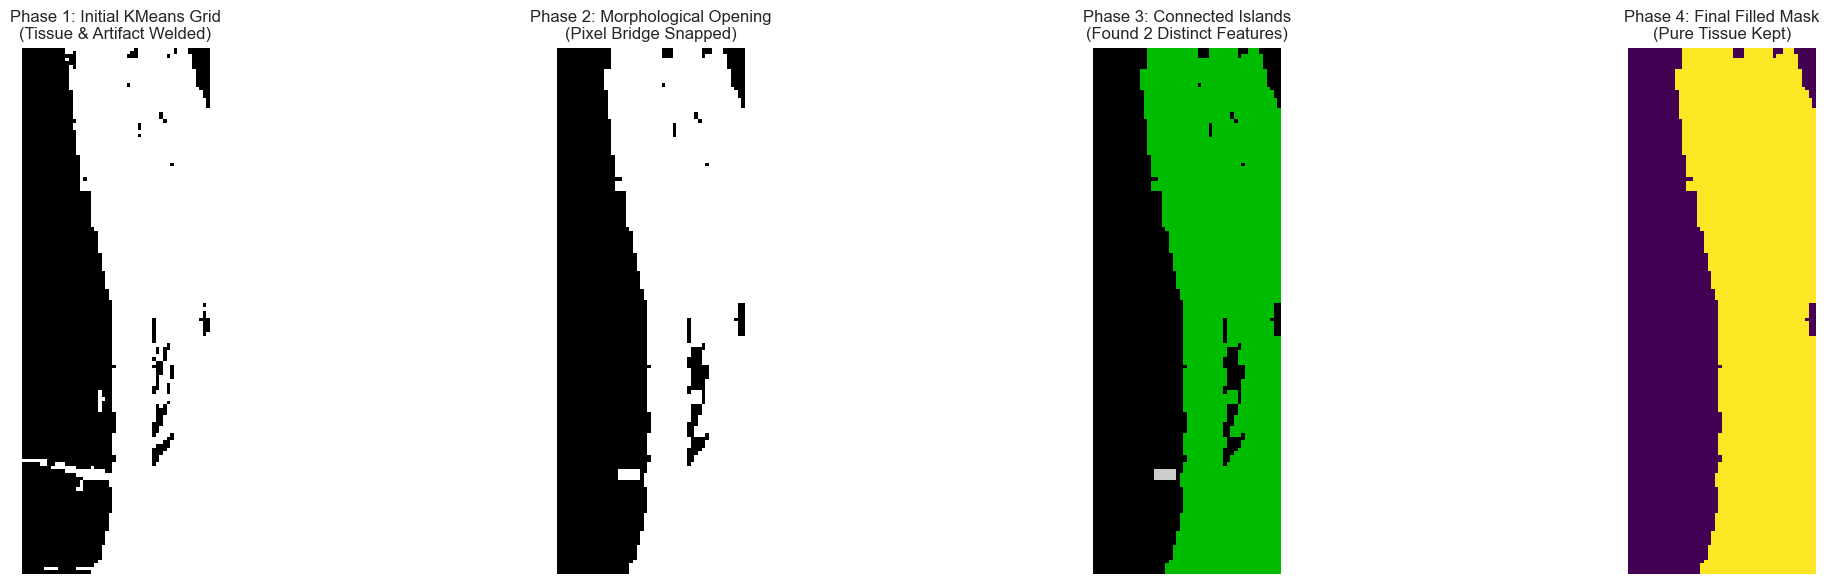

In [7]:
# Create a 4-panel figure to visually track the mask transitions
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Panel 1: The Raw Initial Grid from KMeans
# Shows the tissue and artifact completely welded together
axes[0].imshow(grid, origin='lower', cmap='gray', interpolation='nearest')
axes[0].set_title("Phase 1: Initial KMeans Grid\n(Tissue & Artifact Welded)")

# Panel 2: The Morphological Opening
# Shows the exact moment the thin pixel bridge is sliced open
axes[1].imshow(grid_disconnected, origin='lower', cmap='gray', interpolation='nearest')
axes[1].set_title("Phase 2: Morphological Opening\n(Pixel Bridge Snapped)")

# Panel 3: The Connected Component Islands
# Colors each isolated piece of data a different shade to find the biggest one
axes[2].imshow(labeled_grid, origin='lower', cmap='nipy_spectral', interpolation='nearest')
axes[2].set_title(f"Phase 3: Connected Islands\n(Found {num_features} Distinct Features)")

# Panel 4: The Final Extracted Mask
# The isolated, solid tissue block with internal holes completely sealed
axes[3].imshow(clean_mask, origin='lower', cmap='viridis', interpolation='nearest')
axes[3].set_title("Phase 4: Final Filled Mask\n(Pure Tissue Kept)")

# Clean up layout and display the pipeline
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### 4. HDBSCAN

In [8]:
# Scale data and run HDBSCAN
X_scaled = StandardScaler().fit_transform(df_clean[z_parameters])
df_clean['cluster'] = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=5).fit_predict(X_scaled)

num_clusters = df_clean['cluster'].max() + 1
print(f"Number of clusters found: {num_clusters}")

Number of clusters found: 7


### 5. K-means

In [9]:
# Run KMeans using the number of clusters dynamically found by HDBSCAN
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f"Number of clusters used for KMeans: {num_clusters}")

Number of clusters used for KMeans: 7


### 6. Clustering Plots

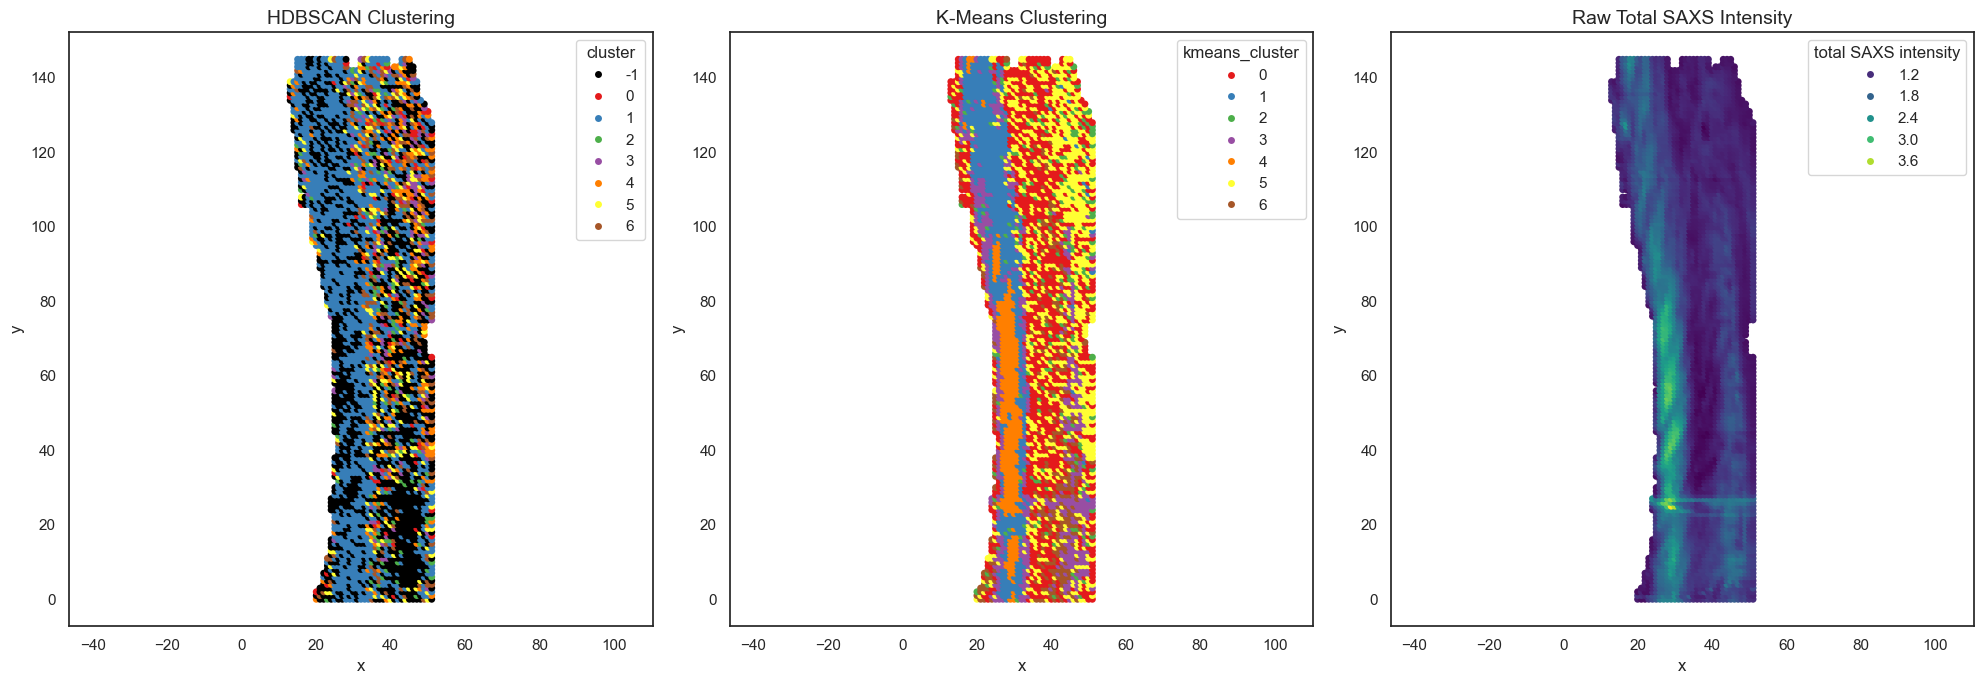

In [10]:
palette_base = sns.color_palette("Set1")
my_colors = {-1: 'black'}
for i in range(num_clusters):
    my_colors[i] = palette_base[i % 10]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# HDBSCAN
sns.scatterplot(
    data=df_clean, 
    x='x', 
    y='y', 
    hue='cluster', 
    palette=my_colors, 
    edgecolor='none', 
    s=25, 
    ax=axes[0]
)
axes[0].set_title('HDBSCAN Clustering', fontsize=14)
axes[0].axis('equal')

# KMeans
sns.scatterplot(
    data=df_clean, 
    x='x', 
    y='y', 
    hue='kmeans_cluster', 
    palette=my_colors, 
    edgecolor='none', 
    s=25, 
    ax=axes[1]
)
axes[1].set_title(f'K-Means Clustering', fontsize=14)
axes[1].axis('equal')

# Total SAXS Intensity
sns.scatterplot(
    data=df_clean, 
    x='x', 
    y='y', 
    hue='total SAXS intensity', 
    palette=my_cmap, 
    edgecolor='none', 
    s=25, 
    ax=axes[2]
)
axes[2].set_title('Raw Total SAXS Intensity', fontsize=14)
axes[2].axis('equal')

plt.tight_layout()
plt.show()

# Sample 2

### 1. Import Data

In [11]:
file_path = 'Data/753828 IQ_fitting.csv'
df_import  = pd.read_csv(file_path)

z_parameters = ['total SAXS intensity', 'area under third order curve', 'D_period']
df = df_import.dropna(subset=z_parameters).copy()

df.head()

,x,y,total SAXS intensity,total_SAXS_norm_0_1,area under third order curve,collagen_third_norm_0_1,percentage_above_baseline,max_recorded_intensity,firstmoment,secondmoment,...,wMu,firstmoment_lu,secondmoment_lu,thirdmoment_lu,skewness_lu,D_period,peak_width,wp,peak_amplitude,fibril_radius
0,0,0,0.338859,0.096547,0.000147,3.054978e-02,69.780377,0.030185,0.286126,0.0819,...,0.175714,0.286080,0.0819,0.023480,0.757759,66.842397,0.006625,0.049551,1,53.816141
1,1,0,0.292420,0.073611,0.000000,1.000000e-09,9.669445,0.004766,0.285300,0.0816,...,0.140204,0.285638,0.0816,0.023340,0.560120,66.606205,0.005125,0.039678,1,67.208103
2,2,0,0.230949,0.043252,0.000311,6.463252e-02,91.352418,0.024309,0.290231,0.0843,...,0.098776,0.290293,0.0843,0.024493,0.095134,65.223377,0.005500,0.028546,1,93.416073
3,3,0,0.262064,0.058619,0.000000,1.000000e-09,49.809060,0.015697,0.285495,0.0816,...,0.205306,0.285478,0.0816,0.023369,0.923555,67.319843,0.007750,0.057486,1,46.388337
4,4,0,0.283853,0.069380,0.000017,3.532968e-03,54.900894,0.015244,0.295424,0.0874,...,0.010000,0.282080,0.0796,0.022446,-0.662833,66.842397,0.001000,0.002820,1,945.626478


### 2. Plots

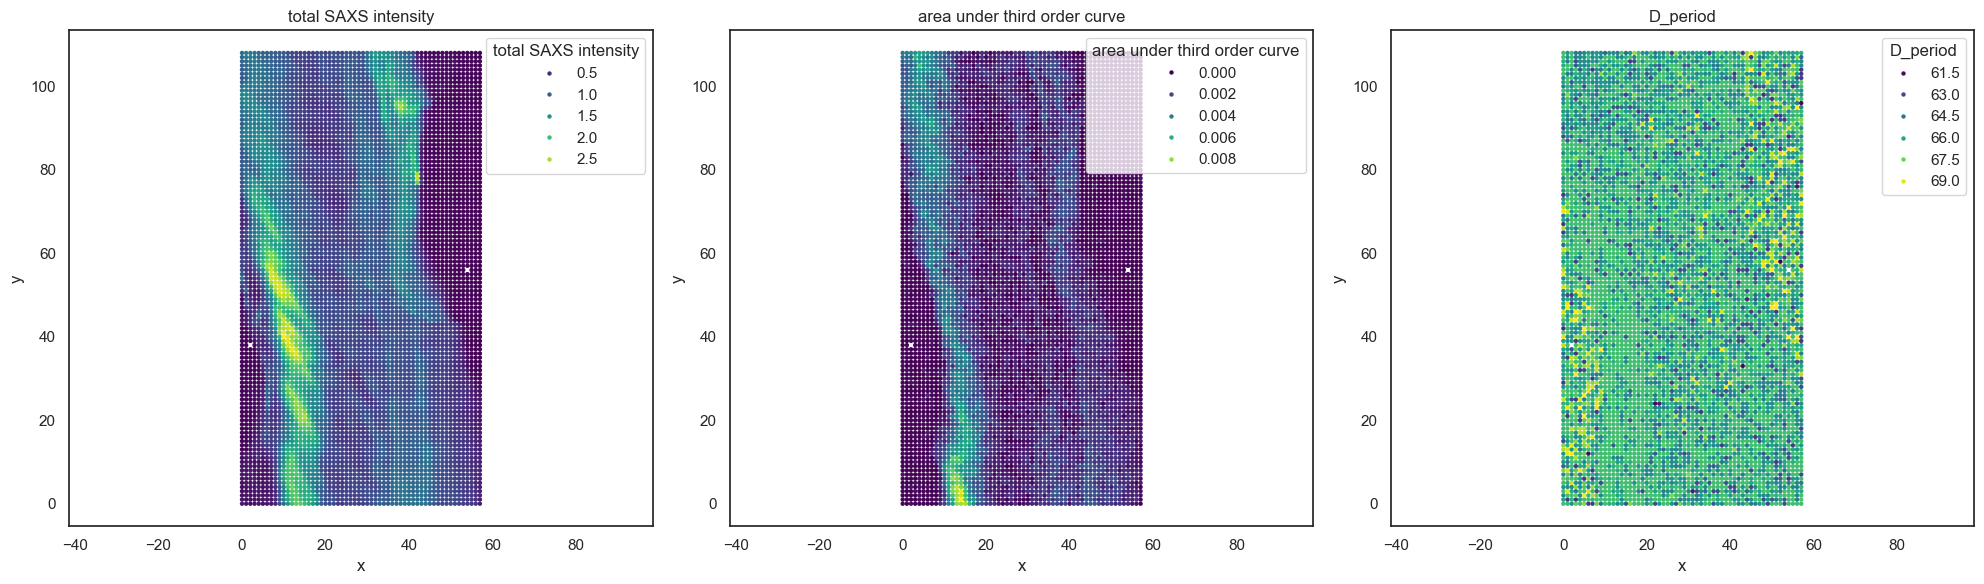

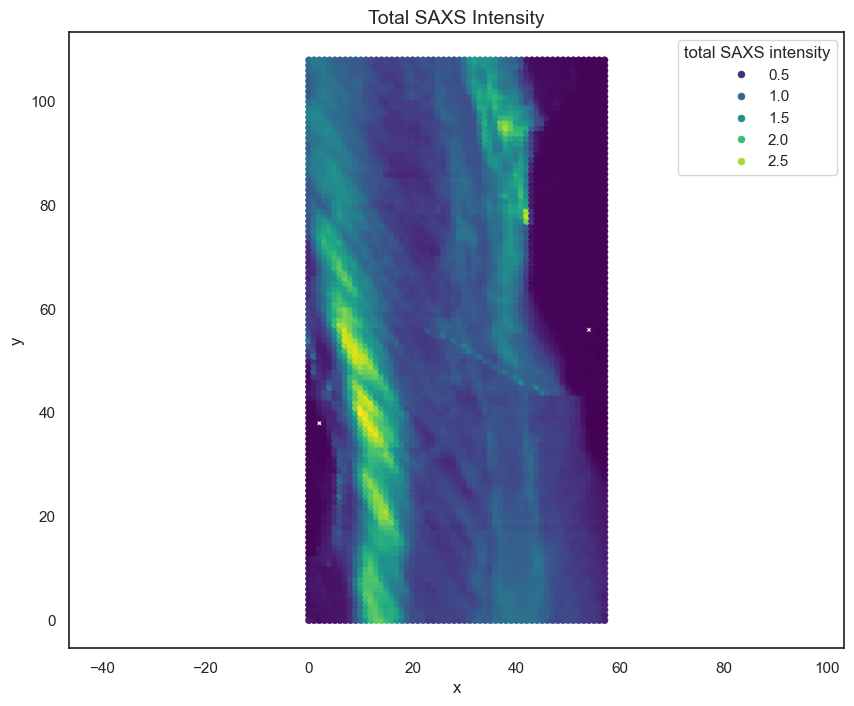

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, param in enumerate(z_parameters):
    sns.scatterplot(
        data=df,
        x='x',
        y='y',
        hue=param,
        palette=my_cmap,
        edgecolor='none',
        s=10,
        ax=axes[i]
    )

    axes[i].set_title(param)
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

# Total SAXS Intensity
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='x', 
    y='y', 
    hue='total SAXS intensity', 
    palette=my_cmap,   
    edgecolor=None, 
    s=25
)
plt.title('Total SAXS Intensity', fontsize=14)
plt.axis('equal')
plt.show()

### 3. Segmentation

In [13]:
# 1. Map the raw spatial coordinates to a zero-indexed integer pixel grid
x_grid = (df['x'] - df['x'].min()).astype(int)
y_grid = (df['y'] - df['y'].min()).astype(int)

grid_width = x_grid.max() + 1
grid_height = y_grid.max() + 1
grid = np.zeros((grid_height, grid_width))

# 2 Normal thresholding (Previously we used K-means for thresolding)
foreground_mask = (df['total SAXS intensity'] > 0.6).astype(int)
grid[y_grid, x_grid] = foreground_mask

# 3. Apply morphological opening
grid_disconnected = binary_opening(grid, structure=np.ones((3, 3)))

# 4. Group physically touching pixels into isolated components
labeled_grid, num_features = label(grid_disconnected)
sizes = np.bincount(labeled_grid.ravel())
sizes[0] = 0  # Exclude the background air count

# 5. Isolate the single largest continuous mass
largest_island_id = sizes.argmax()
clean_mask = (labeled_grid == largest_island_id)

# 6. Fill any small internal structural voids within the mask
clean_mask = binary_fill_holes(clean_mask)

# 7. Map the grid mask back onto the dataframe and filter rows
df['is_real_tissue'] = clean_mask[y_grid, x_grid]
df_clean = df[df['is_real_tissue'] == 1].copy()

print(f"Original points: {len(df)}")
print(f"Cleaned tissue points: {len(df_clean)}")

Original points: 6320
Cleaned tissue points: 4686


#### 3.1 Visualisation

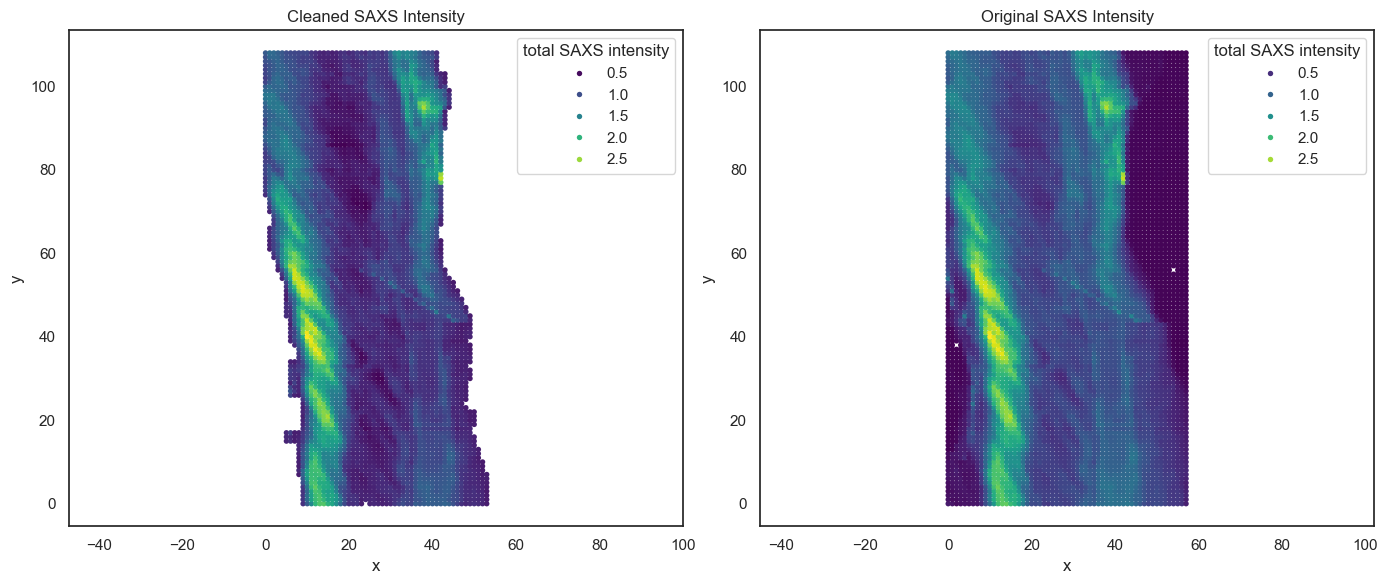

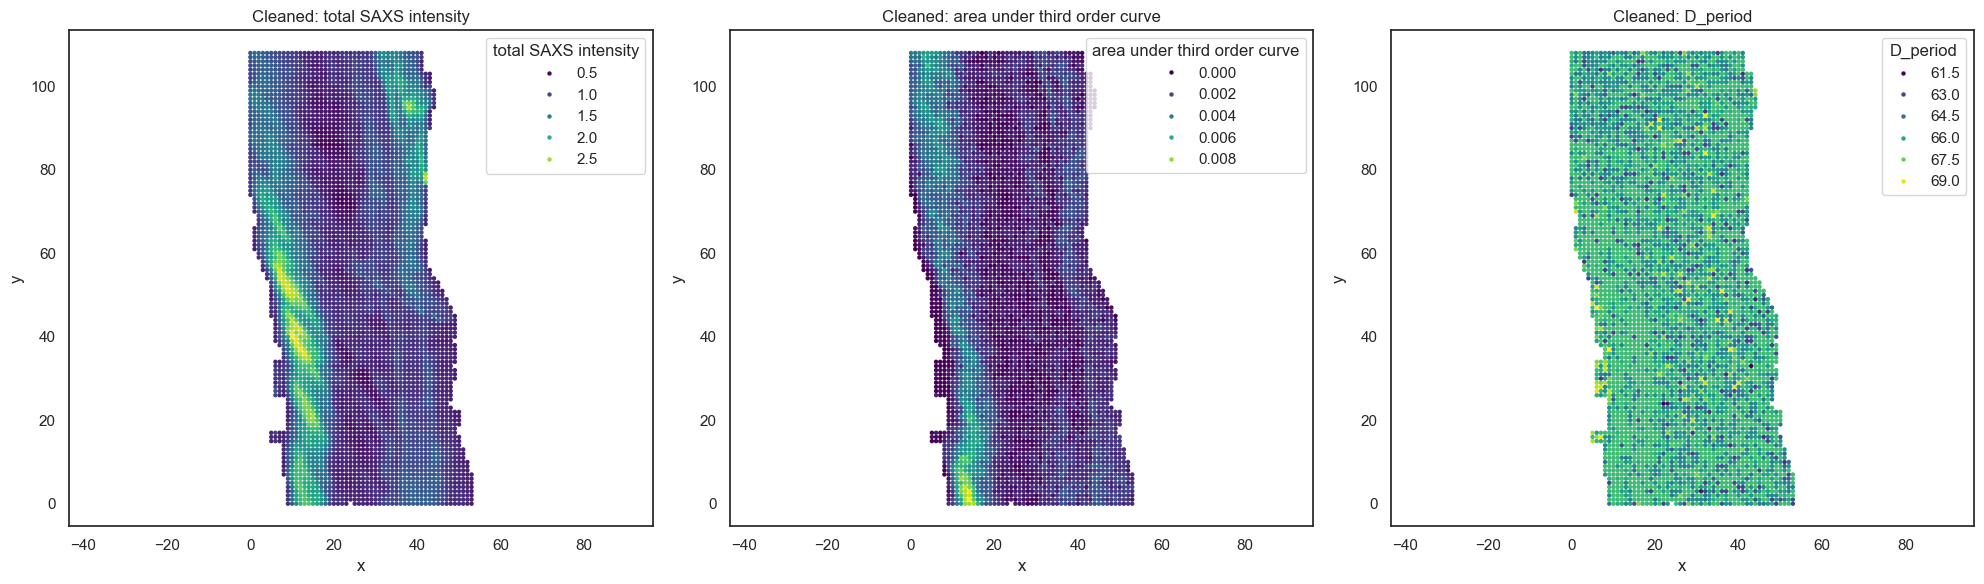

In [14]:
# Plot the cleaned SAXS Intensity and the original SAXS Intensity side-by-side for comparison
fig, axes = plt.subplots(1,2, figsize=(14, 6))

# Cleaned SAXS Intensity
sns.scatterplot(
    data=df_clean, x='x', y='y', hue='total SAXS intensity',
    palette=my_cmap, edgecolor='none', s=15, ax=axes[0]
)
axes[0].set_title("Cleaned SAXS Intensity")
axes[0].axis('equal')

# Original SAXS Intensity
sns.scatterplot(
    data=df, x='x', y='y', hue='total SAXS intensity',
    palette=my_cmap, edgecolor='none', s=15, ax=axes[1]
)
axes[1].set_title("Original SAXS Intensity")
axes[1].axis('equal')

plt.tight_layout()
plt.show()


# 4. Plot all 3 parameters side-by-side to verify
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, param in enumerate(z_parameters):
    sns.scatterplot(
        data=df_clean,
        x='x',
        y='y',
        hue=param,
        palette=my_cmap if param != 'D_period' else 'viridis',
        edgecolor='none',
        s=10,
        ax=axes[i]
    )
    axes[i].set_title(f"Cleaned: {param}")
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

### 4. HDBSCAN

In [49]:
# Scale data and run HDBSCAN
X_scaled = StandardScaler().fit_transform(df_clean[z_parameters])
df_clean['cluster'] = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=5).fit_predict(X_scaled)

num_clusters = df_clean['cluster'].max() + 1
print(f"Number of clusters found: {num_clusters}")

Number of clusters found: 7


### 5. K-means

In [50]:
# Run KMeans using the number of clusters dynamically found by HDBSCAN
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f"Number of clusters used: {num_clusters}")

Number of clusters used: 7


### 6. Clustering Plots

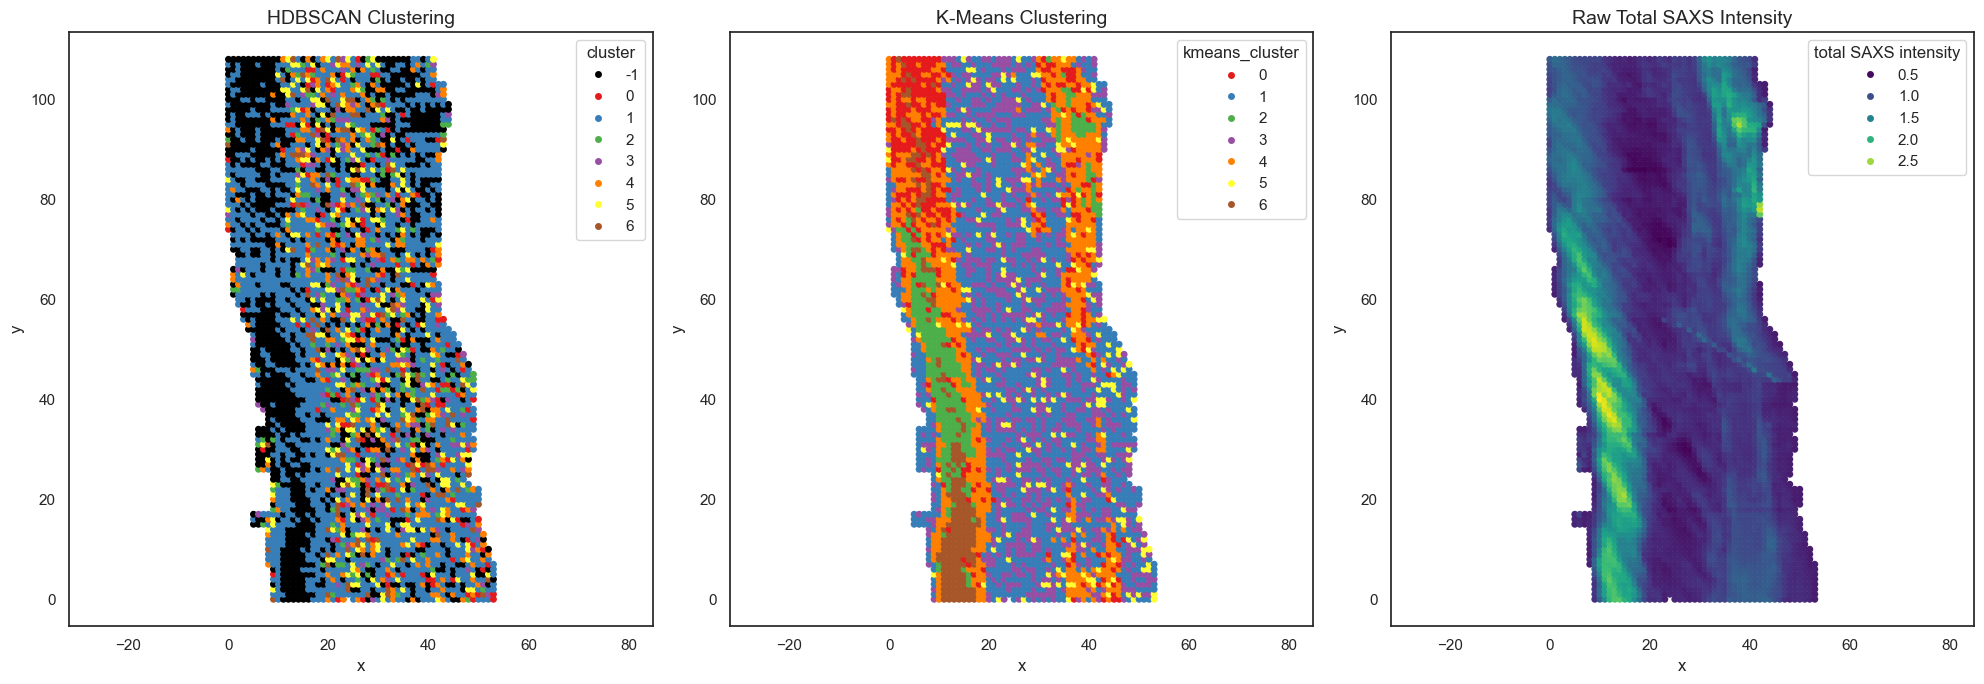

In [ ]:
palette_base = sns.color_palette("Set1")
my_colors = {-1: 'black'}
for i in range(num_clusters):
    my_colors[i] = palette_base[i % 10]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# HDBSCAN
sns.scatterplot(
    data=df_clean, 
    x='x', 
    y='y', 
    hue='cluster', 
    palette=my_colors, 
    edgecolor='none', 
    s=25, 
    ax=axes[0]
)
axes[0].set_title('HDBSCAN Clustering', fontsize=14)
axes[0].axis('equal')

# KMeans
sns.scatterplot(
    data=df_clean, 
    x='x', 
    y='y', 
    hue='kmeans_cluster', 
    palette=my_colors, 
    edgecolor='none', 
    s=25, 
    ax=axes[1]
)
axes[1].set_title(f'K-Means Clustering', fontsize=14)
axes[1].axis('equal')

# Total SAXS Intensity
sns.scatterplot(
    data=df_clean, 
    x='x', 
    y='y', 
    hue='total SAXS intensity', 
    palette=my_cmap, 
    edgecolor='none', 
    s=25, 
    ax=axes[2]
)
axes[2].set_title('Raw Total SAXS Intensity', fontsize=14)
axes[2].axis('equal')

plt.tight_layout()
plt.show()